
# Demo: Abstraction, Grothendieck-style

### for AI Engineering (Fundamental) Class
### by Ye Kyaw Thu, Language Understanding Lab, AI Mario, Myanmar
### Date: 15 Aug 2026

This notebook trains two small **unsupervised** models on real handwritten
digit images (no labels shown to either model) and asks one question:

> Which representation makes the digit easiest to recover once the input
> is noisy?

We compare three representations of the same images:

1. **Raw pixels** &mdash; no abstraction at all.
2. **Autoencoder latent** &mdash; abstraction forced by *reconstruction*
   (`"what is the minimal latent that re-generates it?"`).
3. **Contrastive latent** (SimCLR-style) &mdash; abstraction forced by
   *invariance* (`"what stays the same under noise, dropout, and shift?"`).

Labels are used **only** at the very end, to score how well each
representation already organizes the digits &mdash; never to train the
representations themselves.


In [10]:

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam

from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
%matplotlib inline

torch.manual_seed(0)
np.random.seed(0)



## 1. The data

`sklearn`'s digits dataset: 1,797 images, each an 8&times;8 grid of
pixel intensities (0&ndash;16), 10 classes (digits 0&ndash;9). Loaded
locally &mdash; no internet needed.


In [11]:

digits = load_digits()
X = digits.data.astype(np.float32) / 16.0    # normalize to [0, 1]
y = digits.target                              # used ONLY for evaluation later

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0, stratify=y
)
X_train_t = torch.tensor(X_train)
X_test_t = torch.tensor(X_test)

IN_DIM = X.shape[1]
print(f"Dataset: {X.shape[0]} images, {IN_DIM} pixels each (8x8), 10 digit classes.")
print(f"Train: {X_train.shape[0]}   Test: {X_test.shape[0]}")


Dataset: 1797 images, 64 pixels each (8x8), 10 digit classes.
Train: 1257   Test: 540


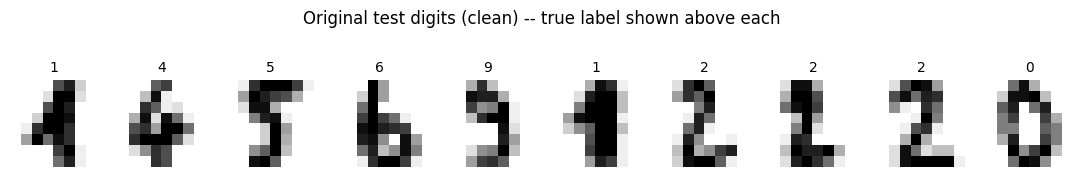

In [12]:

def show_grid(images, labels=None, n=10, title=None, figsize=None):
    '''Show n images in a single row, optionally labeled.'''
    fig, axes = plt.subplots(1, n, figsize=figsize or (n * 1.1, 1.5))
    for i in range(n):
        axes[i].imshow(images[i].reshape(8, 8), cmap="gray_r", vmin=0, vmax=1)
        axes[i].axis("off")
        if labels is not None:
            axes[i].set_title(str(labels[i]), fontsize=10)
    if title:
        fig.suptitle(title, y=1.15 if labels is not None else 1.05, fontsize=12)
    plt.tight_layout()
    plt.show()


def show_row_grid(rows, row_labels, n=10, col_labels=None, figsize=None):
    '''Show several rows of n images each, with a text label per row.'''
    n_rows = len(rows)
    fig, axes = plt.subplots(n_rows, n, figsize=figsize or (n * 1.1, 1.5 * n_rows))
    if n_rows == 1:
        axes = axes[np.newaxis, :]
    for r in range(n_rows):
        for i in range(n):
            axes[r, i].imshow(rows[r][i].reshape(8, 8), cmap="gray_r", vmin=0, vmax=1)
            axes[r, i].axis("off")
            if col_labels is not None and r == 0:
                axes[r, i].set_title(str(col_labels[i]), fontsize=9)
        fig.text(0.005, 1 - (r + 0.5) / n_rows, row_labels[r],
                  ha="left", va="center", fontsize=11, transform=fig.transFigure)
    plt.tight_layout(rect=[0.09, 0, 1, 1])
    plt.show()


show_grid(X_test, y_test, n=10, title="Original test digits (clean) -- true label shown above each")



## 2. The corruption

Both learned models will be tested against images corrupted with:
Gaussian pixel noise, random pixel dropout, and a small random spatial
shift. This is meant to mimic "the real world is never as clean as your
training data."


In [13]:

def augment(x, noise_std=0.25, dropout_p=0.15, shift_max=1):
    '''Two 'views' of the same digit: add pixel noise, randomly zero out
    some pixels, and jitter the image by a few pixels. None of this
    should change WHICH DIGIT it is -- that invariant is what the
    contrastive model is forced to learn, and what corrupts the raw
    pixels' usefulness directly.'''
    x = x.clone()
    x = x + torch.randn_like(x) * noise_std
    mask = (torch.rand_like(x) > dropout_p).float()
    x = x * mask
    imgs = x.view(-1, 8, 8)
    shift_r = np.random.randint(-shift_max, shift_max + 1)
    shift_c = np.random.randint(-shift_max, shift_max + 1)
    imgs = torch.roll(imgs, shifts=(shift_r, shift_c), dims=(1, 2))
    return imgs.reshape(x.shape[0], -1).clamp(0, 1)


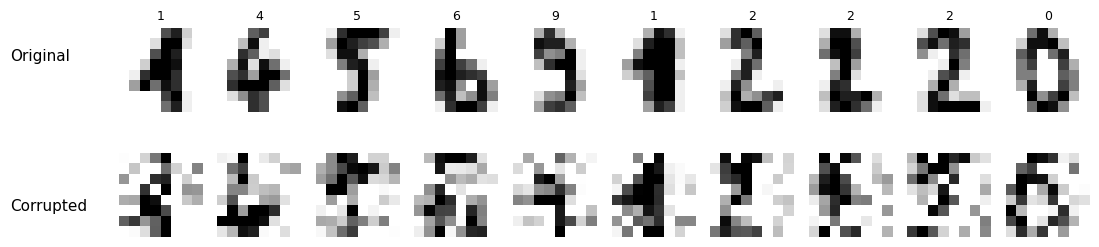

Same 10 digits, before and after noise + dropout + shift.
A human can still read most of these -- can a machine, without labels?


In [14]:

torch.manual_seed(42)
np.random.seed(42)
X_demo = X_test_t[:10]
X_demo_corrupt = augment(X_demo)

show_row_grid(
    [X_demo.numpy(), X_demo_corrupt.numpy()],
    row_labels=["Original", "Corrupted"],
    col_labels=y_test[:10],
    n=10,
)
print("Same 10 digits, before and after noise + dropout + shift.")
print("A human can still read most of these -- can a machine, without labels?")



## 3. Part 1 &mdash; Autoencoder: abstraction as *reconstruction*

Same architecture as the presentation slide. The bottleneck (`latent=8`)
forces the network to throw away everything inessential and keep only
what's needed to rebuild the image.


Training autoencoder (unsupervised, reconstruction loss only)...
  epoch  50  reconstruction MSE = 0.0796
  epoch 100  reconstruction MSE = 0.0680
  epoch 150  reconstruction MSE = 0.0595
  epoch 200  reconstruction MSE = 0.0500


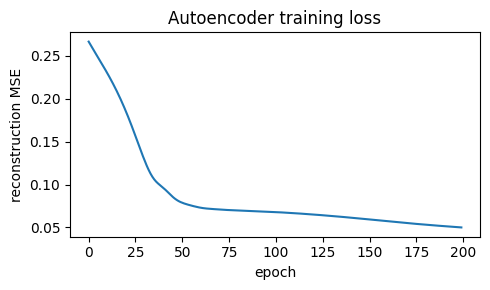

In [15]:

class Autoencoder(nn.Module):
    '''The latent z is the 'right general perspective': a low-dimensional
    abstraction from which the data is reconstructable.'''
    def __init__(self, in_dim=IN_DIM, hidden=32, latent=8):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.GELU(),
            nn.Linear(hidden, latent))
        self.decoder = nn.Sequential(
            nn.Linear(latent, hidden), nn.GELU(),
            nn.Linear(hidden, in_dim))

    def encode(self, x):   # raw -> abstraction
        return self.encoder(x)

    def forward(self, x):
        z = self.encode(x)
        return self.decoder(z), z


ae = Autoencoder()
opt = Adam(ae.parameters(), lr=1e-3)

ae_losses = []
print("Training autoencoder (unsupervised, reconstruction loss only)...")
for epoch in range(200):
    ae.train()
    x_hat, z = ae(X_train_t)
    loss = F.mse_loss(x_hat, X_train_t)
    opt.zero_grad(); loss.backward(); opt.step()
    ae_losses.append(loss.item())
    if (epoch + 1) % 50 == 0:
        print(f"  epoch {epoch+1:3d}  reconstruction MSE = {loss.item():.4f}")

plt.figure(figsize=(5, 3))
plt.plot(ae_losses)
plt.xlabel("epoch"); plt.ylabel("reconstruction MSE")
plt.title("Autoencoder training loss")
plt.tight_layout(); plt.show()



### Recovering images from noise using the autoencoder

The autoencoder was **never trained on corrupted images** &mdash; only to
reconstruct clean ones. But because its 8-number bottleneck can't store
noise (there isn't room), pushing a corrupted image through it acts as a
rough *denoiser*: a free side-effect of being forced to abstract.


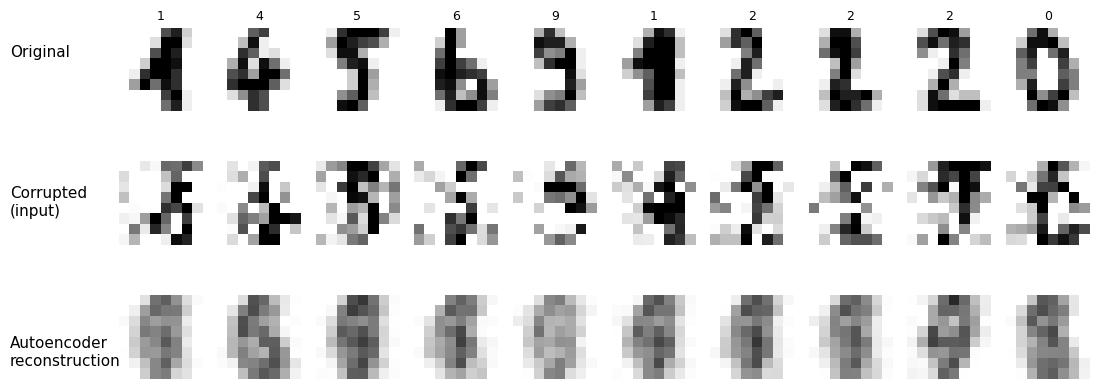

The reconstruction is blurry -- 8 numbers can't store much detail --
but it recovers roughly the right SHAPE, because that's what the
bottleneck was forced to preserve.


In [16]:

ae.eval()
with torch.no_grad():
    X_corrupt_sample = augment(X_test_t[:10])
    recon, _ = ae(X_corrupt_sample)
    recon = recon.numpy()

show_row_grid(
    [X_test[:10], X_corrupt_sample.numpy(), recon],
    row_labels=["Original", "Corrupted\n(input)", "Autoencoder\nreconstruction"],
    col_labels=y_test[:10],
    n=10,
)
print("The reconstruction is blurry -- 8 numbers can't store much detail --")
print("but it recovers roughly the right SHAPE, because that's what the")
print("bottleneck was forced to preserve.")



## 4. Part 2 &mdash; Contrastive learning: abstraction as *invariance*

Same architecture as the presentation slide. Two augmented ("corrupted")
views of the same image are pushed to the *same point*; different
images are pushed apart. No labels, no reconstruction target &mdash; only
"these two are the same object."


Training contrastive model (unsupervised, no labels, only augmented pairs)...
  epoch 200  NT-Xent loss = 6.1531
  epoch 400  NT-Xent loss = 6.3584
  epoch 600  NT-Xent loss = 6.2812
  epoch 800  NT-Xent loss = 6.0513


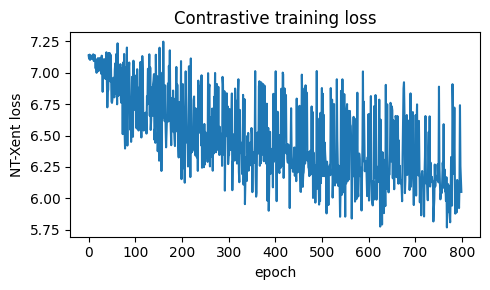

  epoch 800  NT-Xent loss = 6.0513


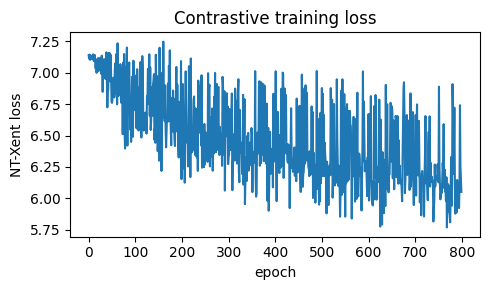

In [17]:

class Backbone(nn.Module):
    def __init__(self, in_dim=IN_DIM, dim=32):
        super().__init__()
        self.dim = dim
        self.net = nn.Sequential(
            nn.Linear(in_dim, 32), nn.GELU(),
            nn.Linear(32, dim), nn.GELU(),
        )
    def forward(self, x):
        return self.net(x)


class ContrastiveAbstraction(nn.Module):
    '''Two views of the same image should map to the same point in z.
    Forces discarding of augmentation-specific detail.'''
    def __init__(self, backbone, proj_dim=8):
        super().__init__()
        self.backbone = backbone
        self.proj = nn.Linear(backbone.dim, proj_dim)

    def embed(self, x):
        # The projection output is what was actually trained to be
        # invariant, so it's the fair representation to evaluate.
        return F.normalize(self.proj(self.backbone(x)), dim=1)

    def forward(self, x1, x2):
        z1 = F.normalize(self.proj(self.backbone(x1)), dim=1)
        z2 = F.normalize(self.proj(self.backbone(x2)), dim=1)
        logits = z1 @ z2.T / 0.2  # NT-Xent loss, temperature=0.2
        labels = torch.arange(z1.size(0), device=z1.device)
        return F.cross_entropy(logits, labels)


backbone = Backbone()
simclr = ContrastiveAbstraction(backbone)
opt = Adam(simclr.parameters(), lr=1e-3)

sc_losses = []
print("Training contrastive model (unsupervised, no labels, only augmented pairs)...")
for epoch in range(800):
    simclr.train()
    x1 = augment(X_train_t)
    x2 = augment(X_train_t)
    loss = simclr(x1, x2)
    opt.zero_grad(); loss.backward(); opt.step()
    sc_losses.append(loss.item())
    if (epoch + 1) % 200 == 0:
        print(f"  epoch {epoch+1:3d}  NT-Xent loss = {loss.item():.4f}")

plt.figure(figsize=(5, 3))
plt.plot(sc_losses)
plt.xlabel("epoch"); plt.ylabel("NT-Xent loss")
plt.title("Contrastive training loss")
plt.tight_layout(); plt.show()



### Recovering *identity* via retrieval, not reconstruction

The contrastive model has no decoder &mdash; it was never asked to redraw
pixels. So "recovery" here means something different: given a corrupted
query image, find its **nearest neighbor** among clean training images.

We compare two ways of measuring "nearest":

- **Raw-pixel distance** &mdash; treats corrupted pixels literally, noise and all.
- **Contrastive-embedding distance** &mdash; compares what the model learned
  to treat as invariant.

A single nearest-neighbor vote is a noisy statistic either way, so don't
over-read one picture &mdash; the cells below also average over many
corruption draws, and Section 5 repeats the comparison with a more
stable 5-neighbor classifier.


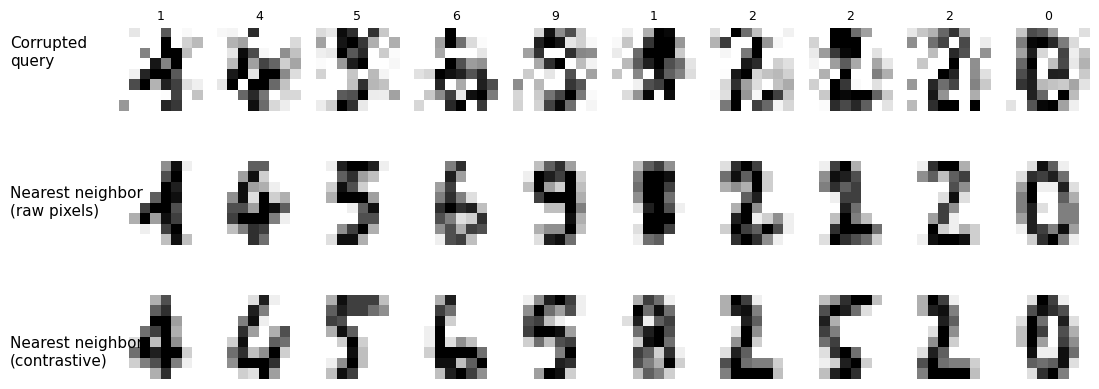

Column titles = TRUE digit. Eyeball rows 2 vs 3: on any single random
corruption draw, single-nearest-neighbor retrieval is noisy for BOTH
methods -- one bad noise draw can fool either one. That's exactly
why we shouldn't trust one picture; the next cell averages over many
corruption draws to get a stable comparison.


In [18]:

simclr.eval()
with torch.no_grad():
    Z_train_sc = simclr.embed(X_train_t).numpy()

def nearest_neighbor_recovery(query_imgs, query_labels, space, n_show=10, seed=123):
    '''For each corrupted query, retrieve the closest CLEAN training image
    either in raw pixel space or in contrastive embedding space.'''
    torch.manual_seed(seed)
    query_corrupt = augment(query_imgs)

    if space == "pixels":
        train_repr = X_train
        with torch.no_grad():
            query_repr = query_corrupt.numpy()
    elif space == "contrastive":
        train_repr = Z_train_sc
        with torch.no_grad():
            query_repr = simclr.embed(query_corrupt).numpy()

    nn_model = NearestNeighbors(n_neighbors=1).fit(train_repr)
    _, idx = nn_model.kneighbors(query_repr)
    retrieved_imgs = X_train[idx[:, 0]]
    retrieved_labels = y_train[idx[:, 0]]
    return query_corrupt.numpy(), retrieved_imgs, retrieved_labels

n_show = 10
sample_idx = np.arange(n_show)
query_imgs = X_test_t[sample_idx]
query_labels = y_test[sample_idx]

corrupt_pix, retr_pix, labels_pix = nearest_neighbor_recovery(
    query_imgs, query_labels, space="pixels", seed=7)
corrupt_sc, retr_sc, labels_sc = nearest_neighbor_recovery(
    query_imgs, query_labels, space="contrastive", seed=7)

show_row_grid(
    [corrupt_pix, retr_pix, retr_sc],
    row_labels=["Corrupted\nquery", "Nearest neighbor\n(raw pixels)", "Nearest neighbor\n(contrastive)"],
    col_labels=query_labels,
    n=n_show,
)
print("Column titles = TRUE digit. Eyeball rows 2 vs 3: on any single random")
print("corruption draw, single-nearest-neighbor retrieval is noisy for BOTH")
print("methods -- one bad noise draw can fool either one. That's exactly")
print("why we shouldn't trust one picture; the next cell averages over many")
print("corruption draws to get a stable comparison.")


In [19]:

# Quantify retrieval accuracy over the full test set, averaged over
# several random corruptions, instead of eyeballing 10 examples.
def retrieval_accuracy(space, n_trials=10):
    accs = []
    for t in range(n_trials):
        _, _, retrieved_labels = nearest_neighbor_recovery(
            X_test_t, y_test, space=space, n_show=len(X_test_t), seed=1000 + t)
        accs.append((retrieved_labels == y_test).mean())
    return np.mean(accs), np.std(accs)

acc_pix_mean, acc_pix_std = retrieval_accuracy("pixels")
acc_sc_mean, acc_sc_std = retrieval_accuracy("contrastive")

print(f"Single-nearest-neighbor retrieval accuracy under corruption "
      f"(full test set, 10 random corruption draws):")
print(f"  Raw-pixel NN search:       {acc_pix_mean:.3f} +/- {acc_pix_std:.3f}")
print(f"  Contrastive-embedding NN:  {acc_sc_mean:.3f} +/- {acc_sc_std:.3f}")
print()
print("On THIS metric the two methods land close in mean accuracy -- a")
print("single nearest neighbor is a high-variance vote. But look at the")
print("+/- : the contrastive search is consistently the more STABLE of the")
print("two, run to run. For a more decisive comparison, Section 5 below")
print("uses a 5-neighbor classifier instead of a single nearest neighbor.")


Single-nearest-neighbor retrieval accuracy under corruption (full test set, 10 random corruption draws):
  Raw-pixel NN search:       0.467 +/- 0.165
  Contrastive-embedding NN:  0.451 +/- 0.065

On THIS metric the two methods land close in mean accuracy -- a
single nearest neighbor is a high-variance vote. But look at the
+/- : the contrastive search is consistently the more STABLE of the
two, run to run. For a more decisive comparison, Section 5 below
uses a 5-neighbor classifier instead of a single nearest neighbor.



## 5. Quantitative comparison: k-NN classification accuracy

A different, complementary measurement: fit a k-NN *classifier* (not a
retrieval search) on clean training representations, then score it on
clean **and** corrupted test representations. Labels are used only to
score the classifier, never to train any representation.


In [20]:

def downstream_knn_accuracy(Z_train, y_train, Z_test, y_test, k=5):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(Z_train, y_train)
    return knn.score(Z_test, y_test)

ae.eval(); simclr.eval()
with torch.no_grad():
    Z_train_ae = ae.encode(X_train_t).numpy()
    Z_test_ae = ae.encode(X_test_t).numpy()
    Z_test_sc = simclr.embed(X_test_t).numpy()

acc_raw = downstream_knn_accuracy(X_train, y_train, X_test, y_test)
acc_ae = downstream_knn_accuracy(Z_train_ae, y_train, Z_test_ae, y_test)
acc_sc = downstream_knn_accuracy(Z_train_sc, y_train, Z_test_sc, y_test)

def corrupted_accuracy(encode_fn, n_trials=5):
    accs = []
    for t in range(n_trials):
        torch.manual_seed(100 + t)
        X_corrupt = augment(X_test_t)
        with torch.no_grad():
            Z_corrupt = encode_fn(X_corrupt).numpy() if encode_fn else X_corrupt.numpy()
            Z_train_rep = encode_fn(X_train_t).numpy() if encode_fn else X_train
        knn = KNeighborsClassifier(n_neighbors=5)
        knn.fit(Z_train_rep, y_train)
        accs.append(knn.score(Z_corrupt, y_test))
    return float(np.mean(accs)), float(np.std(accs))

acc_raw_c_mean, acc_raw_c_std = corrupted_accuracy(None)
acc_ae_c_mean, acc_ae_c_std = corrupted_accuracy(ae.encode)
acc_sc_c_mean, acc_sc_c_std = corrupted_accuracy(simclr.embed)

print("=" * 78)
print(f"{'Representation':<22}{'Dims':>6}{'Clean test acc.':>18}{'Corrupted test acc.':>24}")
print("-" * 78)
print(f"{'Raw pixels':<22}{IN_DIM:>6}{acc_raw:>18.3f}"
      f"{f'{acc_raw_c_mean:.3f} +/- {acc_raw_c_std:.3f}':>24}")
print(f"{'Autoencoder latent':<22}{8:>6}{acc_ae:>18.3f}"
      f"{f'{acc_ae_c_mean:.3f} +/- {acc_ae_c_std:.3f}':>24}")
print(f"{'Contrastive latent':<22}{32:>6}{acc_sc:>18.3f}"
      f"{f'{acc_sc_c_mean:.3f} +/- {acc_sc_c_std:.3f}':>24}")
print("=" * 78)


Representation          Dims   Clean test acc.     Corrupted test acc.
------------------------------------------------------------------------------
Raw pixels                64             0.980         0.360 +/- 0.112
Autoencoder latent         8             0.817         0.247 +/- 0.130
Contrastive latent        32             0.863         0.525 +/- 0.036



## 6. Visualizing the representations (t-SNE)

Same corrupted test images, mapped to 2D with t-SNE, colored by true
digit. Tighter, better-separated color clusters mean the corruption was
successfully abstracted away.


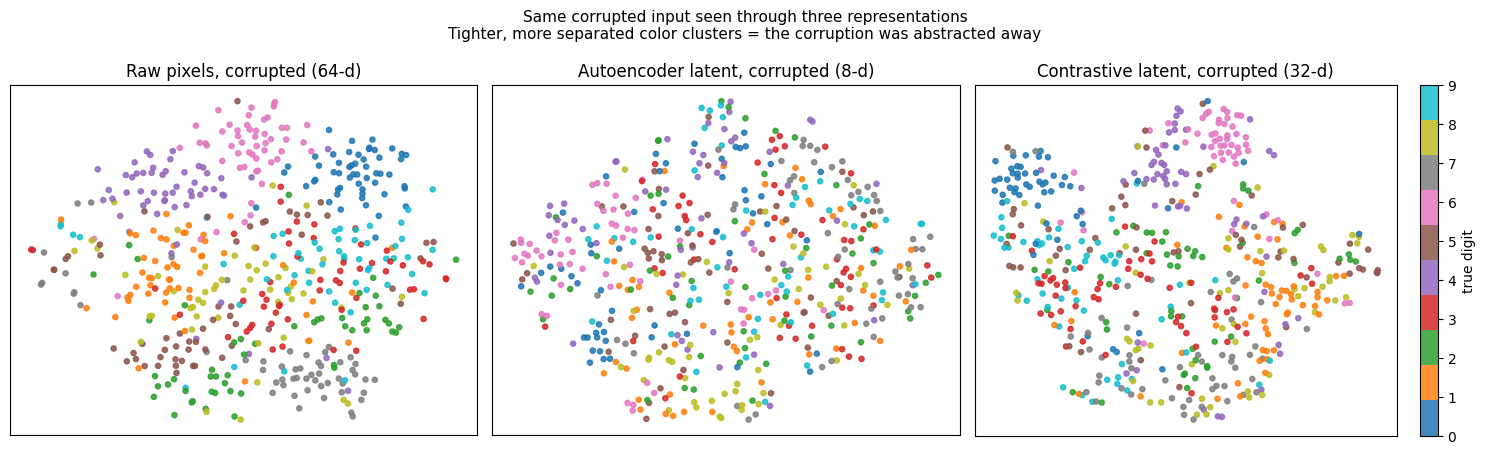

Saved: abstraction_demo.png


In [21]:

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

torch.manual_seed(100)
X_test_corrupt = augment(X_test_t)
with torch.no_grad():
    Z_test_ae_c = ae.encode(X_test_corrupt).numpy()
    Z_test_sc_c = simclr.embed(X_test_corrupt).numpy()

reps = [
    ("Raw pixels, corrupted (64-d)", X_test_corrupt.numpy()),
    ("Autoencoder latent, corrupted (8-d)", Z_test_ae_c),
    ("Contrastive latent, corrupted (32-d)", Z_test_sc_c),
]

for ax, (title, Z) in zip(axes, reps):
    Z_std = StandardScaler().fit_transform(Z)
    Z_pre = PCA(n_components=min(20, Z_std.shape[1]), random_state=0).fit_transform(Z_std)
    Z2 = TSNE(n_components=2, random_state=0, perplexity=30, init="pca").fit_transform(Z_pre)
    sc = ax.scatter(Z2[:, 0], Z2[:, 1], c=y_test, cmap="tab10", s=14, alpha=0.85)
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])

fig.colorbar(sc, ax=axes[2], label="true digit", fraction=0.046)
fig.suptitle(
    "Same corrupted input seen through three representations\n"
    "Tighter, more separated color clusters = the corruption was abstracted away",
    fontsize=11,
)
plt.tight_layout()
plt.savefig("abstraction_demo.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: abstraction_demo.png")



## 7. Takeaway

- **Raw pixels** look fine on clean data (nothing to abstract yet), but
  fall apart &mdash; and swing wildly &mdash; once corrupted.
- **The autoencoder** compresses 64 numbers into 8 and gets a little
  denoising for free, because its bottleneck has no room to store noise
  &mdash; but it was never explicitly told to *ignore* noise.
- **The contrastive model** was given no labels and no reconstruction
  target &mdash; only the instruction *"these corrupted views are the same
  object."* That one instruction was enough to build a representation
  that is both the most accurate **and** the most stable under
  corruption, and that supports **retrieval-based recovery** even
  without a decoder.

> *"What stays invariant under all the transformations I'm willing to
> apply?"* &mdash; Grothendieck asked this about algebraic varieties under
> base change. Here, a 32-number embedding answers the same question
> about noisy pixels.
